In [212]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

trainingdata = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\Documents\Purelogics Internship\Projects\W1-4Titanicsurvival\train.csv")

print(trainingdata.head())

print(trainingdata.columns)


testingdata = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\Documents\Purelogics Internship\Projects\W1-4Titanicsurvival\test.csv")

print(testingdata.head())

print(testingdata.columns)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
In

In [213]:
trainingdata.info()
trainingdata.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64
0.38910778230082704


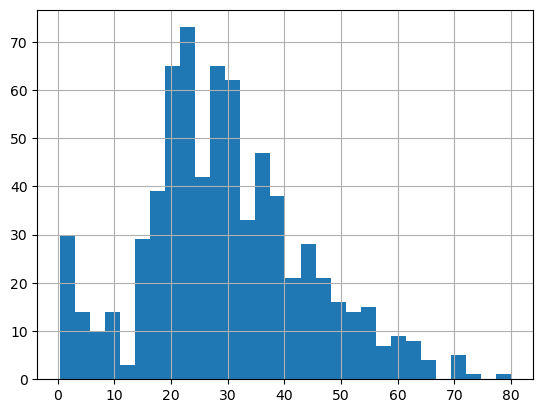

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [214]:
trainingdata = trainingdata.drop("Cabin", axis=1)

trainingdata["Embarked"] = trainingdata["Embarked"].fillna(trainingdata["Embarked"].mode()[0])

print(trainingdata["Age"].describe())

print(trainingdata["Age"].skew())

trainingdata["Age"].hist(bins=30)
plt.show()

trainingdata["Age"] = trainingdata["Age"].fillna(trainingdata["Age"].median())

trainingdata.head()


In [215]:
y = trainingdata["Survived"]
X = trainingdata.drop("Survived", axis=1)

In [216]:
X = X.drop("Ticket", axis=1)

In [217]:
X.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


In [218]:
X = X.drop("Name" , axis = 1)

In [219]:
X.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,3,male,22.0,1,0,7.2500,S
1,2,1,female,38.0,1,0,71.2833,C
2,3,3,female,26.0,0,0,7.9250,S
3,4,1,female,35.0,1,0,53.1000,S
4,5,3,male,35.0,0,0,8.0500,S


In [220]:
X["Embarked"].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [221]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

X["Sex"] = label_encoder.fit_transform(X["Sex"])

In [222]:
from sklearn.preprocessing import OneHotEncoder
onehotencoder = OneHotEncoder(sparse_output = False)
encoded = onehotencoder.fit_transform(X[["Embarked"]])

In [223]:
encoded_df = pd.DataFrame(
    encoded,
    columns=onehotencoder.get_feature_names_out(["Embarked"]),
    index=X.index
)

In [224]:
encoded_df

,Embarked_C,Embarked_Q,Embarked_S
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0
...,...,...,...
886,0.0,0.0,1.0
887,0.0,0.0,1.0
888,0.0,0.0,1.0
889,1.0,0.0,0.0


In [225]:
X = X.drop(columns=["Embarked"])

X = pd.concat([X, encoded_df], axis=1)

In [226]:
X.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,3,1,22.0,1,0,7.2500,0.0,0.0,1.0
1,2,1,0,38.0,1,0,71.2833,1.0,0.0,0.0
2,3,3,0,26.0,0,0,7.9250,0.0,0.0,1.0
3,4,1,0,35.0,1,0,53.1000,0.0,0.0,1.0
4,5,3,1,35.0,0,0,8.0500,0.0,0.0,1.0


In [227]:
testingdata

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [228]:
testingdata.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [229]:
testingdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [230]:
testingdata = testingdata.drop("Cabin" , axis = 1)
testingdata = testingdata.drop("Ticket" , axis = 1)
testingdata = testingdata.drop("Name" , axis = 1)

In [231]:
testingdata.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,892,3,male,34.5,0,0,7.8292,Q
1,893,3,female,47.0,1,0,7.0000,S
2,894,2,male,62.0,0,0,9.6875,Q
3,895,3,male,27.0,0,0,8.6625,S
4,896,3,female,22.0,1,1,12.2875,S


In [232]:
X_test = testingdata
X_test.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,892,3,male,34.5,0,0,7.8292,Q
1,893,3,female,47.0,1,0,7.0000,S
2,894,2,male,62.0,0,0,9.6875,Q
3,895,3,male,27.0,0,0,8.6625,S
4,896,3,female,22.0,1,1,12.2875,S


In [233]:
X_test["Sex"] = label_encoder.transform(X_test["Sex"])

In [234]:
X_test.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,892,3,1,34.5,0,0,7.8292,Q
1,893,3,0,47.0,1,0,7.0000,S
2,894,2,1,62.0,0,0,9.6875,Q
3,895,3,1,27.0,0,0,8.6625,S
4,896,3,0,22.0,1,1,12.2875,S


In [235]:
X_test_encoded = onehotencoder.transform(X_test[["Embarked"]])

In [236]:
encoded_df_test = pd.DataFrame(
    X_test_encoded,
    columns=onehotencoder.get_feature_names_out(["Embarked"]),
    index=X_test.index
)

In [237]:
encoded_df_test.head()

,Embarked_C,Embarked_Q,Embarked_S
0,0.0,1.0,0.0
1,0.0,0.0,1.0
2,0.0,1.0,0.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0


In [238]:
X_test = X_test.drop(columns=["Embarked"])

X_test = pd.concat([X_test, encoded_df_test], axis=1)

In [239]:
X_test.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,892,3,1,34.5,0,0,7.8292,0.0,1.0,0.0
1,893,3,0,47.0,1,0,7.0000,0.0,0.0,1.0
2,894,2,1,62.0,0,0,9.6875,0.0,1.0,0.0
3,895,3,1,27.0,0,0,8.6625,0.0,0.0,1.0
4,896,3,0,22.0,1,1,12.2875,0.0,0.0,1.0


In [240]:
X_train, Xtest, y_train, ytest = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [241]:
model = LogisticRegression(max_iter = 10000)

In [242]:
model.fit(X_train,y_train)

LogisticRegression(max_iter=10000)

In [243]:
y_pred = model.predict(Xtest)

In [244]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(ytest, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8044692737430168


In [245]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[89 16]
 [19 55]]


In [246]:
from sklearn.metrics import precision_score

precision = precision_score(ytest, y_pred)

print("Precision:", precision)

Precision: 0.7746478873239436


In [247]:
from sklearn.metrics import recall_score

recall = recall_score(ytest, y_pred)

print("Recall:", recall)

Recall: 0.7432432432432432


In [248]:
from sklearn.metrics import f1_score

f1 = f1_score(ytest, y_pred)

print("F1 Score:", f1)

F1 Score: 0.7586206896551724


In [249]:
from sklearn.metrics import classification_report

print(classification_report(ytest, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



In [253]:
X_test["Age"] = X_test["Age"].fillna(trainingdata["Age"].median())
X_test["Fare"] = X_test["Fare"].fillna(trainingdata["Fare"].median())
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    int64  
 3   Age          418 non-null    float64
 4   SibSp        418 non-null    int64  
 5   Parch        418 non-null    int64  
 6   Fare         418 non-null    float64
 7   Embarked_C   418 non-null    float64
 8   Embarked_Q   418 non-null    float64
 9   Embarked_S   418 non-null    float64
dtypes: float64(5), int64(5)
memory usage: 32.8 KB


In [254]:
predictions = model.predict(X_test)

In [255]:
submission = pd.DataFrame({
    "PassengerId": X_test["PassengerId"],
    "Survived": predictions
})

In [256]:
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [258]:
submission.to_csv("submission.csv", index=False)